In [14]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures

# 🏠 Real Estate Price Prediction in Bulgaria

## Tutorial Project

This notebook demonstrates how to build a machine learning model for predicting real estate prices using multiple data sources.

We will go step by step:
- Data creation and merging
- Feature engineering
- Mathematical modeling
- Model comparison

Author: [Emiliyan]

## 1. Problem Definition

Real estate prices depend on multiple factors:
- Property characteristics (size, rooms)
- Location
- Economic indicators

### Goal:
Build a model that predicts property prices.

### Why is this important?
- Helps buyers make decisions
- Useful for investors
- Demonstrates real-world ML workflow

## 2. Data Sources

We simulate two independent datasets:

1. Property data
2. Economic data

Then we merge them.

In [15]:
np.random.seed(42)
n = 300

properties = pd.DataFrame({
    'size': np.random.randint(30, 150, n),
    'rooms': np.random.randint(1, 5, n),
    'city': np.random.choice(['Sofia', 'Plovdiv', 'Varna'], n)
})

economy = pd.DataFrame({
    'city': ['Sofia', 'Plovdiv', 'Varna'],
    'salary': [3000, 2000, 2200],
    'population': [1300000, 350000, 340000]
})

# Merge
data = properties.merge(economy, on='city')

# Target
data['price'] = (
    data['size'] * 1200 +
    data['rooms'] * 8000 +
    data['salary'] * 3 +
    np.random.randint(-20000, 20000, n)
)

data.head()

,size,rooms,city,salary,population,price
0,132,2,Plovdiv,2000,350000,198292
1,81,3,Sofia,3000,1300000,111215
2,122,3,Plovdiv,2000,350000,184112
3,44,4,Varna,2200,340000,106361
4,136,4,Varna,2200,340000,190215


## 3. Feature Engineering

We create new features to improve model performance.

Examples:
- Price per room approximation
- Size per room

In [16]:
data['size_per_room'] = data['size'] / data['rooms']
data['salary_per_person'] = data['salary'] / data['population']

data.head()

,size,rooms,city,salary,population,price,size_per_room,salary_per_person
0,132,2,Plovdiv,2000,350000,198292,66.000000,0.005714
1,81,3,Sofia,3000,1300000,111215,27.000000,0.002308
2,122,3,Plovdiv,2000,350000,184112,40.666667,0.005714
3,44,4,Varna,2200,340000,106361,11.000000,0.006471
4,136,4,Varna,2200,340000,190215,34.000000,0.006471


Convert categorical variable (city) into numeric.

In [17]:
data = pd.get_dummies(data, columns=['city'], drop_first=True)

## 4. Exploratory Data Analysis

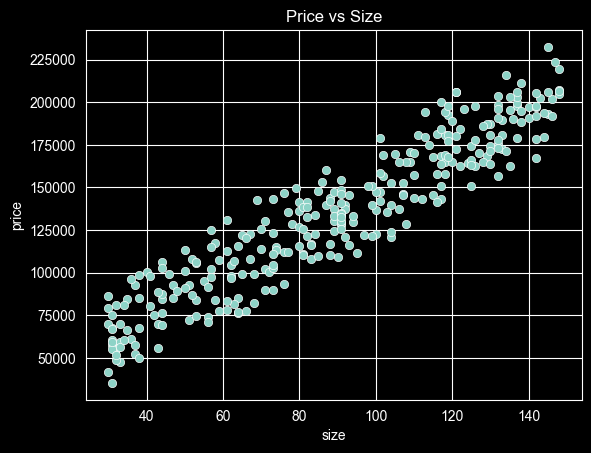

In [18]:
plt.figure()
sns.scatterplot(x=data['size'], y=data['price'])
plt.title("Price vs Size")
plt.show()

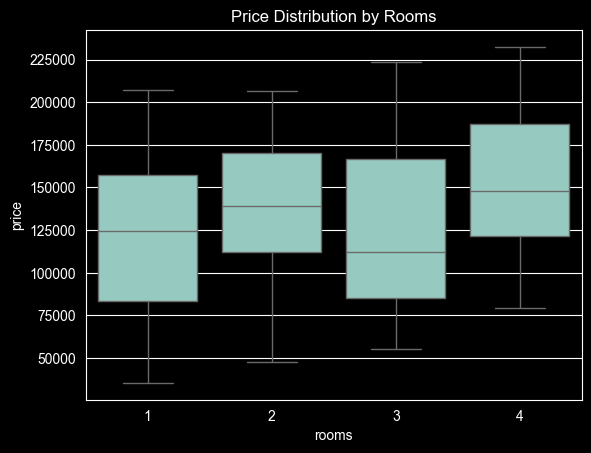

In [19]:
plt.figure()
sns.boxplot(x=data['rooms'], y=data['price'])
plt.title("Price Distribution by Rooms")
plt.show()

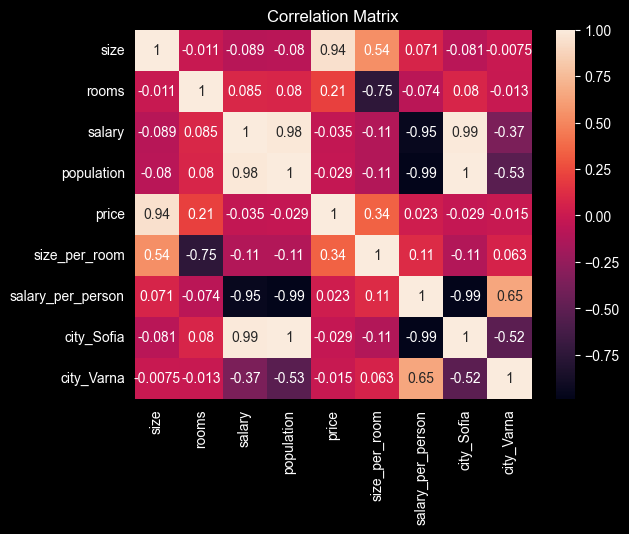

In [20]:
plt.figure()
sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

## 5. Mathematical Model

We use Linear Regression:

y = β0 + β1x1 + ... + βn xn

### Loss Function:
MSE = (1/n) Σ(y - ŷ)^2

Goal: minimize MSE

In [21]:
X = data.drop('price', axis=1)
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling

We scale the data so models like Ridge and Lasso work properly.

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Linear Regression

In [23]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

## 7. Polynomial Regression

We add non-linear relationships.

In [24]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

X_train_p, X_test_p, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

poly_model = LinearRegression()
poly_model.fit(X_train_p, y_train)

y_pred_poly = poly_model.predict(X_test_p)

## 8. Regularization Models

In [25]:
ridge = Ridge()
lasso = Lasso(max_iter=10000)

ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)
y_pred_lasso = lasso.predict(X_test_scaled)